In [ ]:
#Загрузка и первичное изучение данных

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка данных
df = pd.read_csv('credit_risk_dataset.csv')

# Просмотр данных
print(df.shape)
print(df.head())
print(df.info())
print(df['loan_status'].value_counts(normalize=True))

(32581, 12)
   person_age  person_income person_home_ownership  person_emp_length  \
0          22          59000                  RENT              123.0   
1          21           9600                   OWN                5.0   
2          25           9600              MORTGAGE                1.0   
3          23          65500                  RENT                4.0   
4          24          54400                  RENT                8.0   

  loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \
0    PERSONAL          D      35000          16.02            1   
1   EDUCATION          B       1000          11.14            0   
2     MEDICAL          C       5500          12.87            1   
3     MEDICAL          C      35000          15.23            1   
4     MEDICAL          C      35000          14.27            1   

   loan_percent_income cb_person_default_on_file  cb_person_cred_hist_length  
0                 0.59                         Y                   

In [ ]:
#Имеются пропуски в данных в person_emp_length loan_int_rate а также есть несбалансированность 0.218164 дефолтов против 0.781836

In [ ]:
#Исследовательский анализ данных

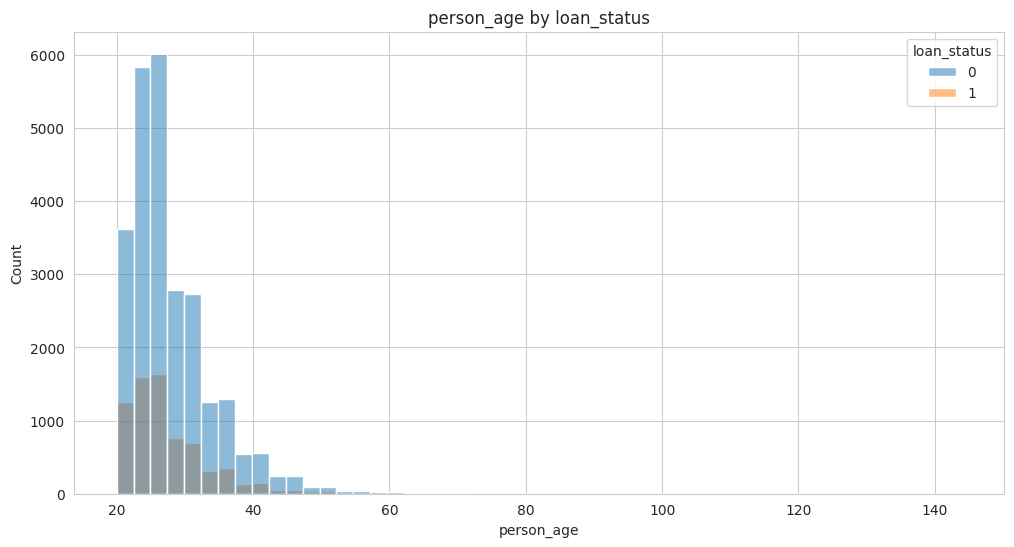

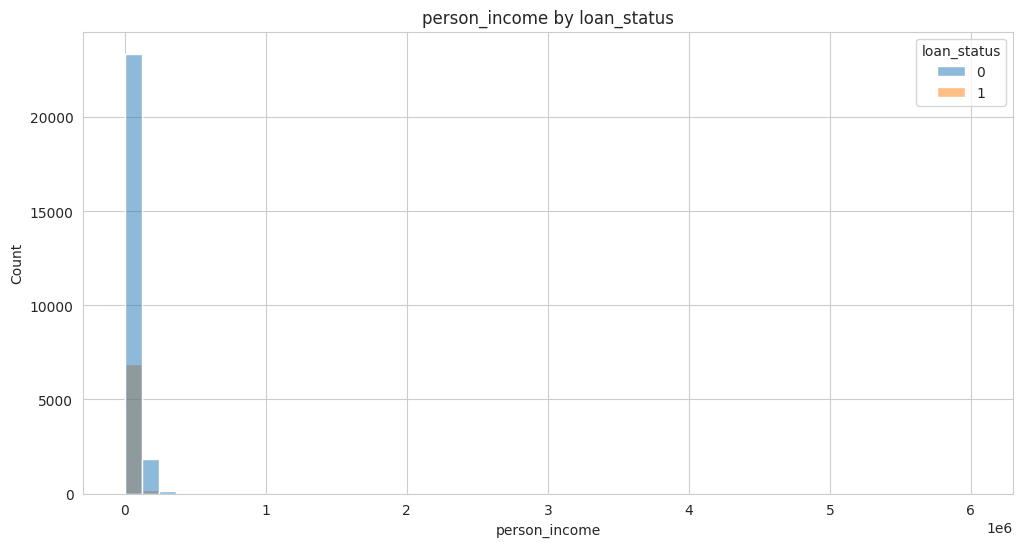

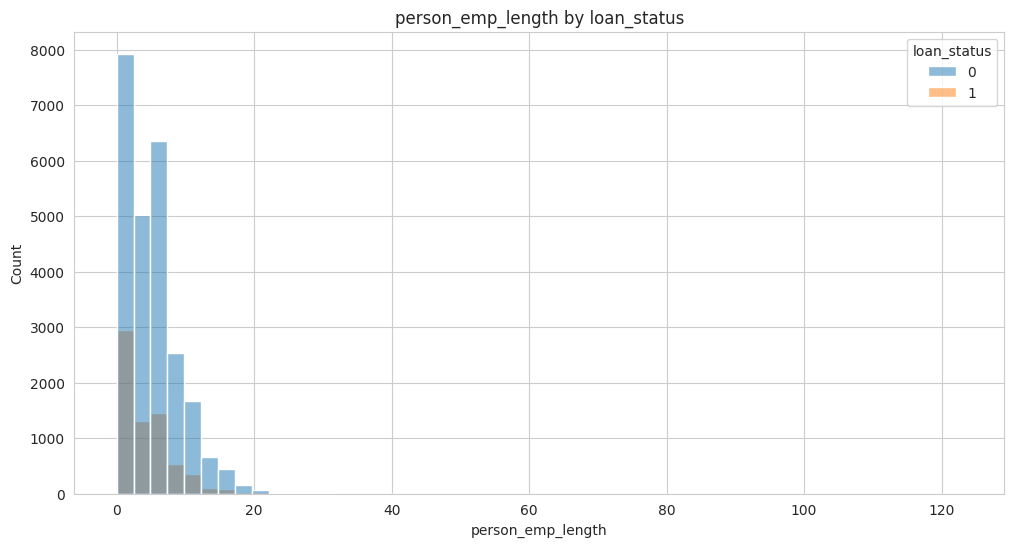

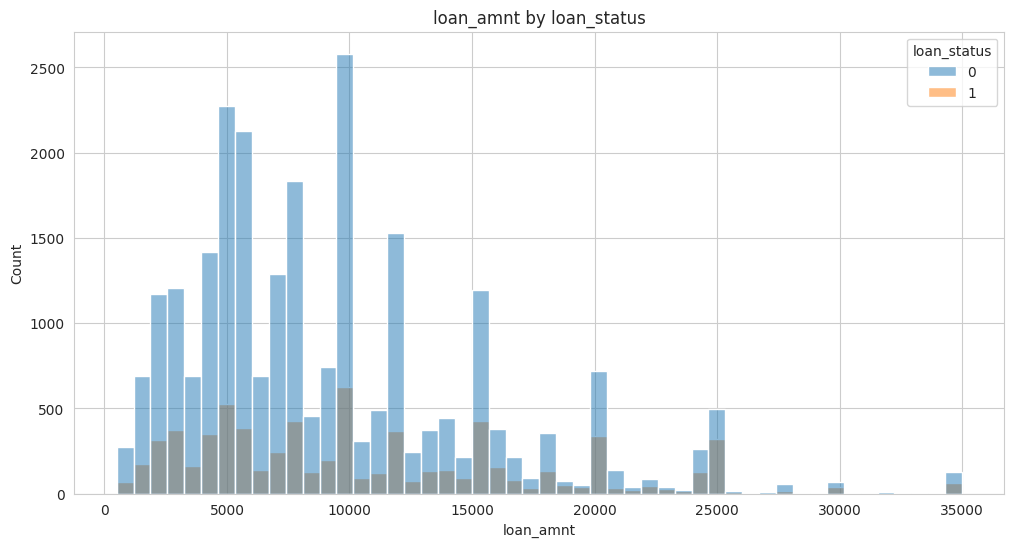

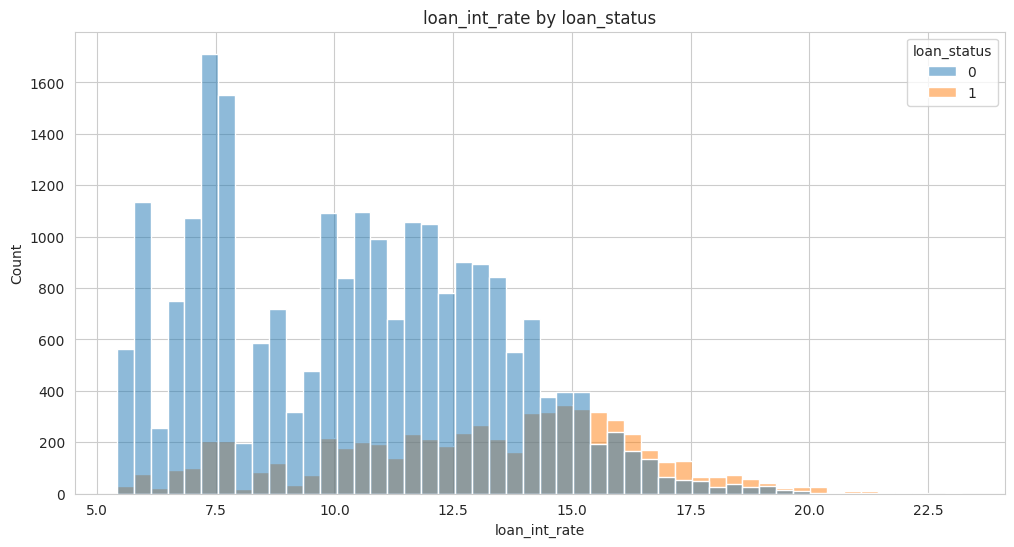

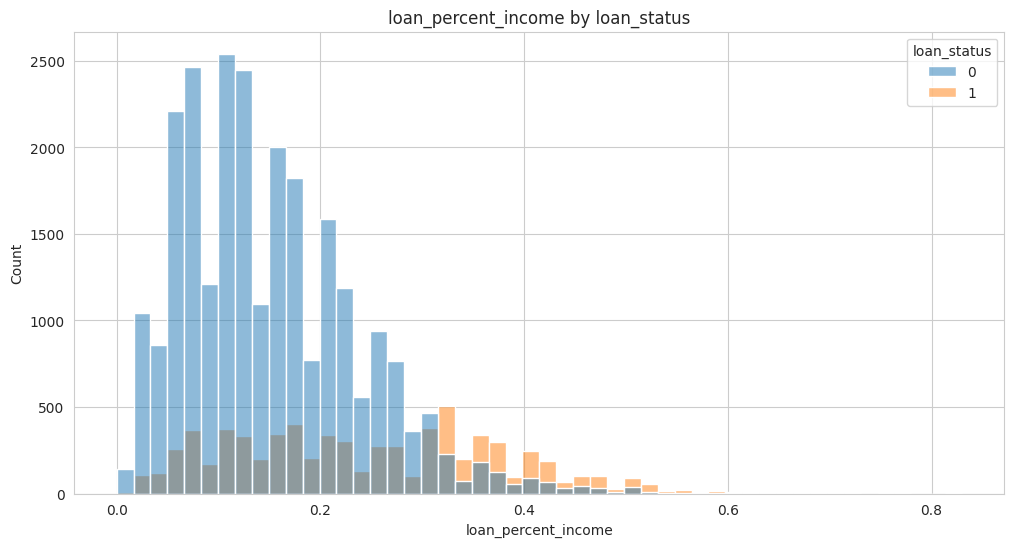

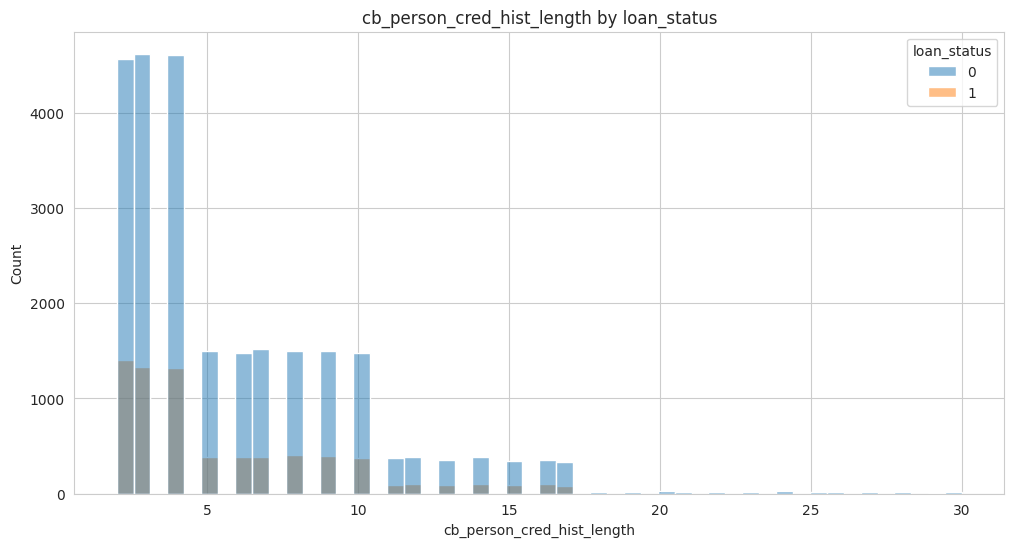

In [11]:
# Числовые признаки
numeric_cols = ['person_age', 'person_income', 'person_emp_length',
                'loan_amnt', 'loan_int_rate', 'loan_percent_income',
                'cb_person_cred_hist_length']

# Распределение по каждому признаку в разрезе target
for col in numeric_cols:
    plt.figure()
    sns.histplot(data=df, x=col, hue='loan_status', bins=50, alpha=0.5)
    plt.title(f'{col} by loan_status')
    plt.show()

<Figure size 1200x600 with 0 Axes>

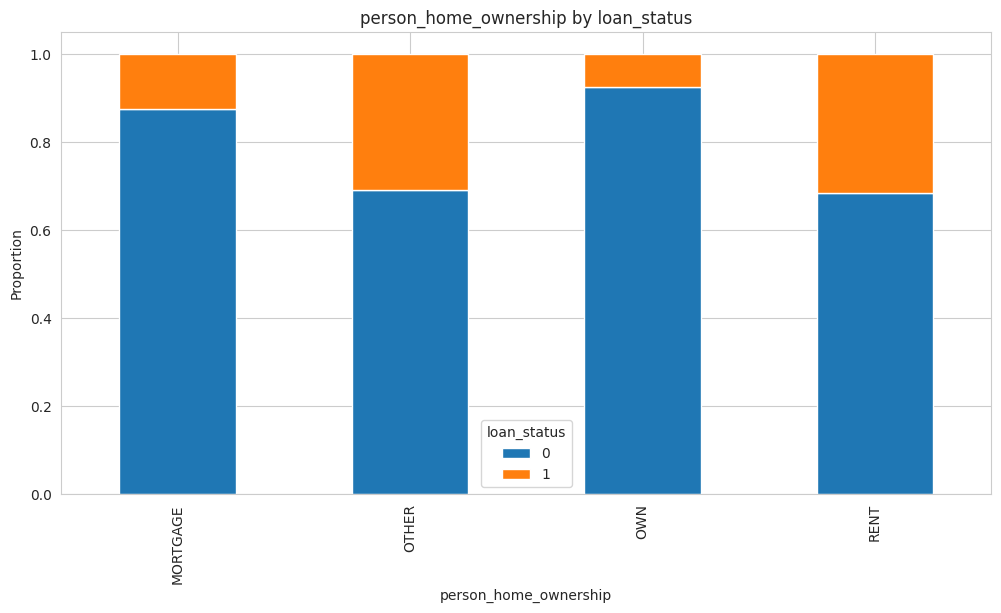

<Figure size 1200x600 with 0 Axes>

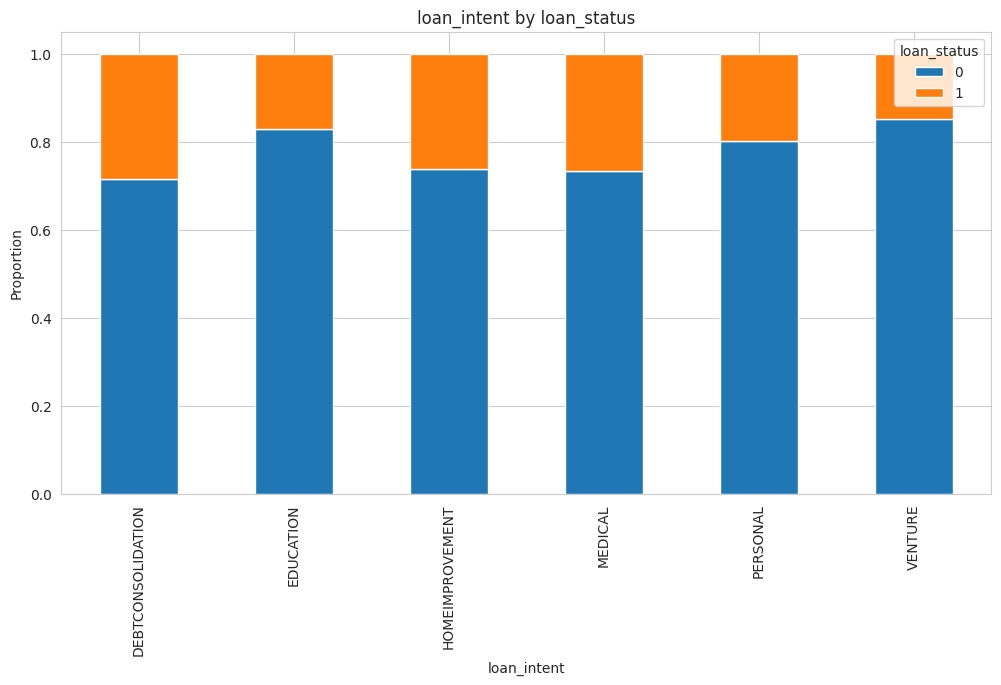

<Figure size 1200x600 with 0 Axes>

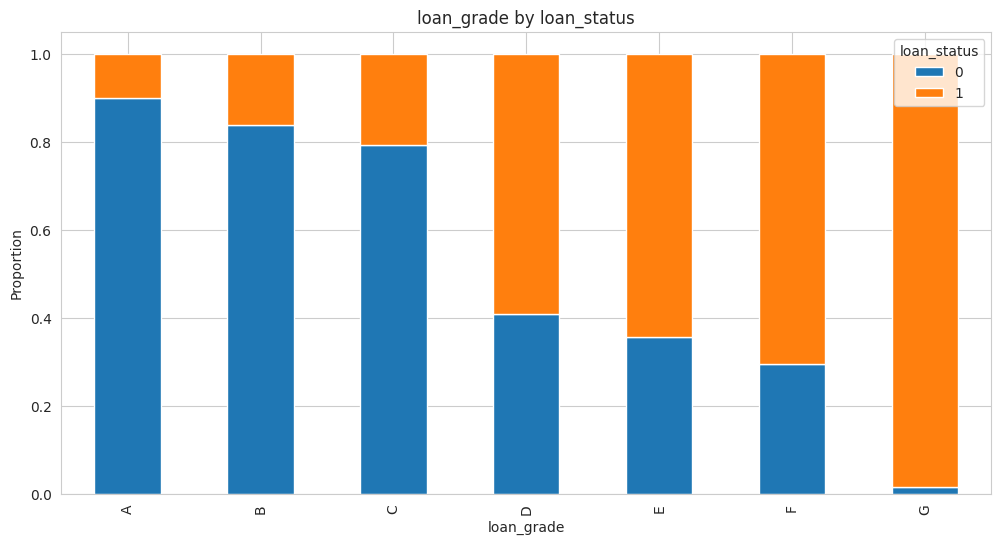

<Figure size 1200x600 with 0 Axes>

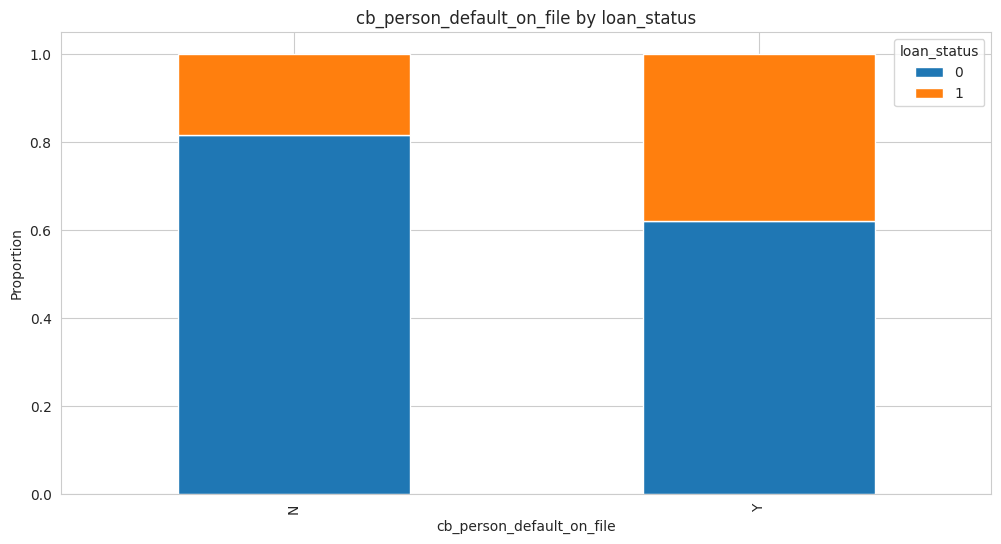

In [12]:
# Категориальные признаки
cat_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

for col in cat_cols:
    plt.figure()
    pd.crosstab(df[col], df['loan_status'], normalize='index').plot(kind='bar', stacked=True)
    plt.title(f'{col} by loan_status')
    plt.ylabel('Proportion')
    plt.show()

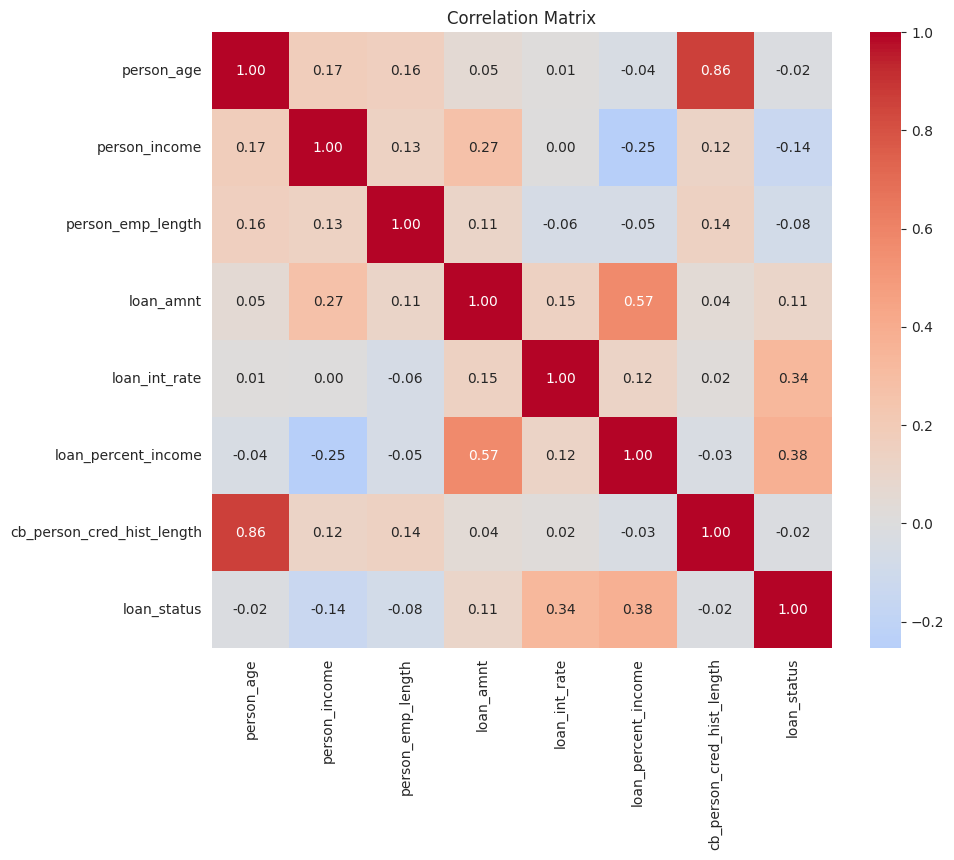

In [13]:
# 3. Корреляционная матрица для числовых признаков
plt.figure(figsize=(10, 8))
corr_matrix = df[numeric_cols + ['loan_status']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

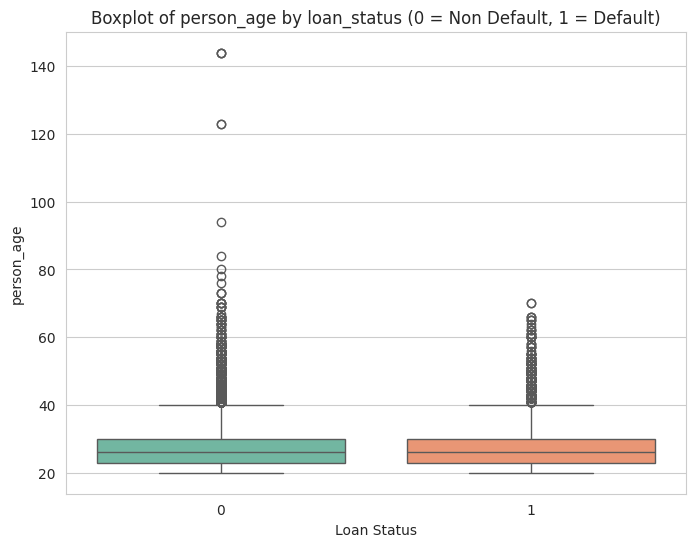

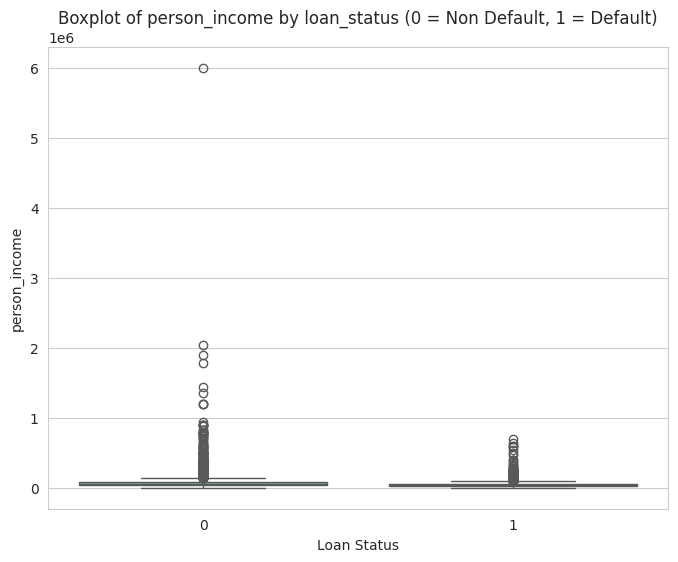

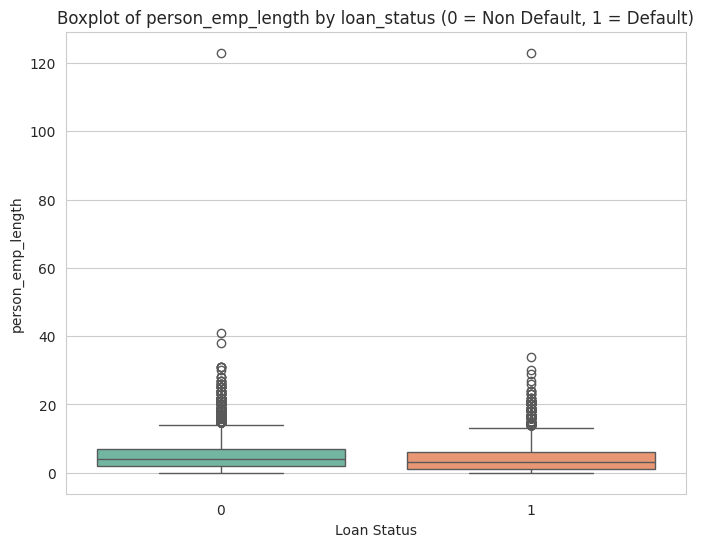

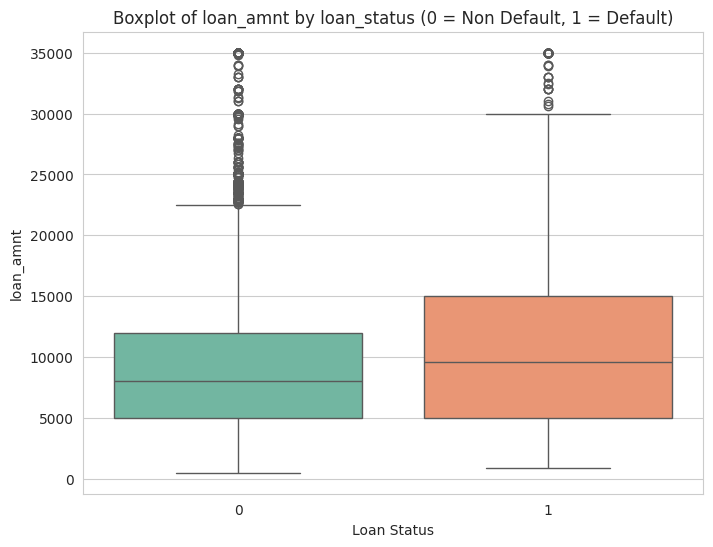

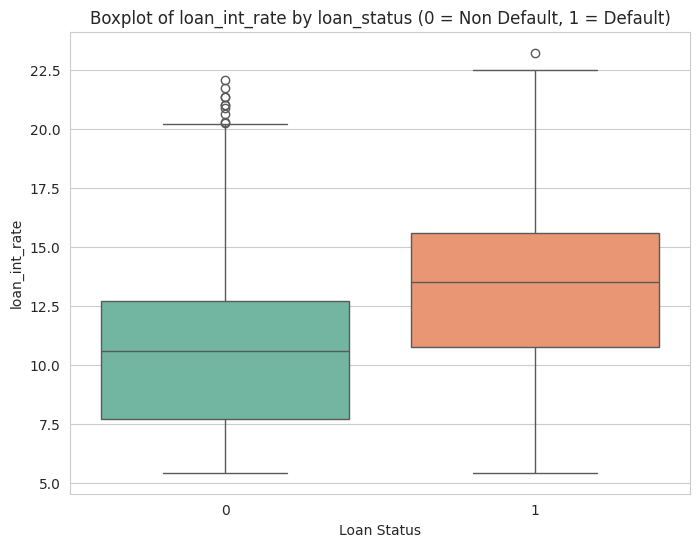

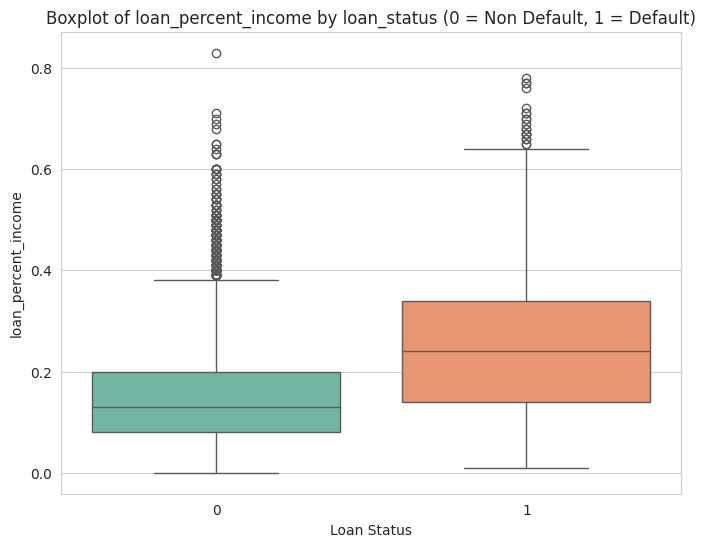

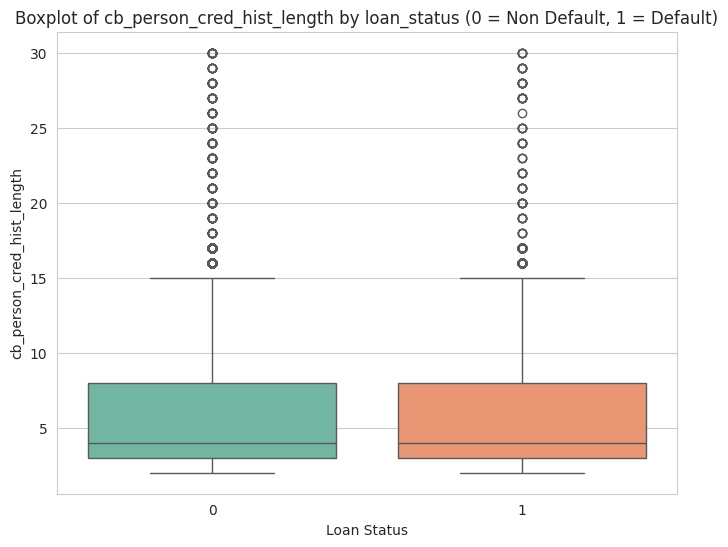

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Числовые признаки (все, кроме целевого)
numeric_cols = ['person_age', 'person_income', 'person_emp_length',
                'loan_amnt', 'loan_int_rate', 'loan_percent_income',
                'cb_person_cred_hist_length']

# Настройка стиля
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Построение boxplot по каждому признаку
for col in numeric_cols:
    plt.figure(figsize=(8, 6))
    sns.boxplot(data=df, x='loan_status', y=col, hue='loan_status',
                palette='Set2', legend=False)
    plt.title(f'Boxplot of {col} by loan_status (0 = Non Default, 1 = Default)')
    plt.xlabel('Loan Status')
    plt.ylabel(col)
    plt.show()

In [ ]:
#чистка данных

In [15]:
# 1. Возраст (были обнаружен > 80 лет. удаляю )
df = df[df['person_age'] <= 80]

# 2. Доход (ограничение 99-м процентилем)
upper_income = df['person_income'].quantile(0.99)
df = df[df['person_income'] <= upper_income]

# 3. Рабочий стаж (ограничение 99-м процентилем)
upper_emp = df['person_emp_length'].quantile(0.99)
df = df[df['person_emp_length'] <= upper_emp]

# 4. Сумма кредита (ограничение 99-м процентилем)
upper_loan = df['loan_amnt'].quantile(0.99)
df = df[df['loan_amnt'] <= upper_loan]

# 5. Процентная ставка (ограничение 99-м процентилем)
upper_rate = df['loan_int_rate'].quantile(0.99)
df = df[df['loan_int_rate'] <= upper_rate]

# 6. Отношение кредита к доходу (ограничение 99-м процентилем)
upper_pct = df['loan_percent_income'].quantile(0.99)
df = df[df['loan_percent_income'] <= upper_pct]


In [16]:
print(f"Осталось строк после чистки: {df.shape[0]}")
print(f"Было удалено ~{(32581 - df.shape[0]) / 32581 * 100:.1f}% данных")

Осталось строк после чистки: 27264
Было удалено ~16.3% данных


In [ ]:
#после чистки

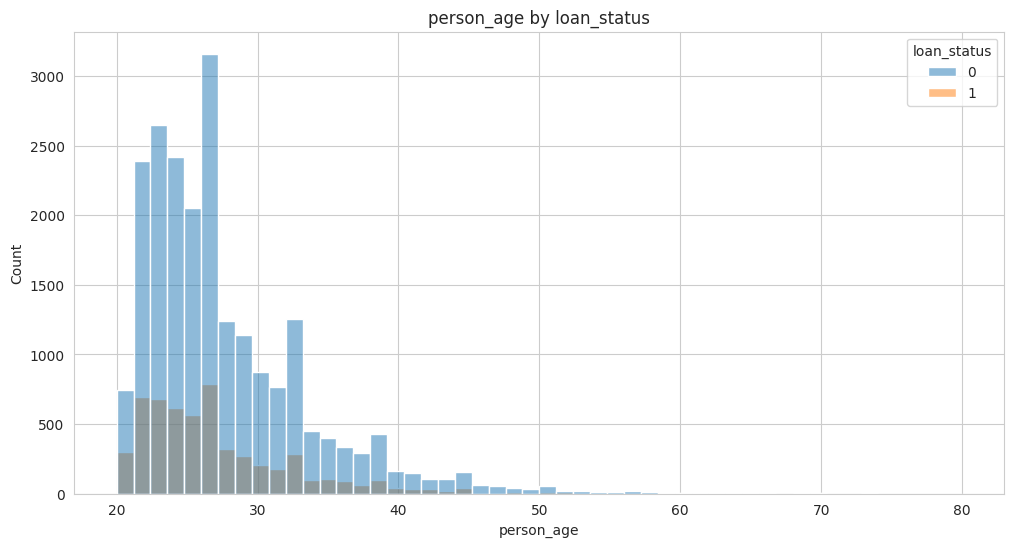

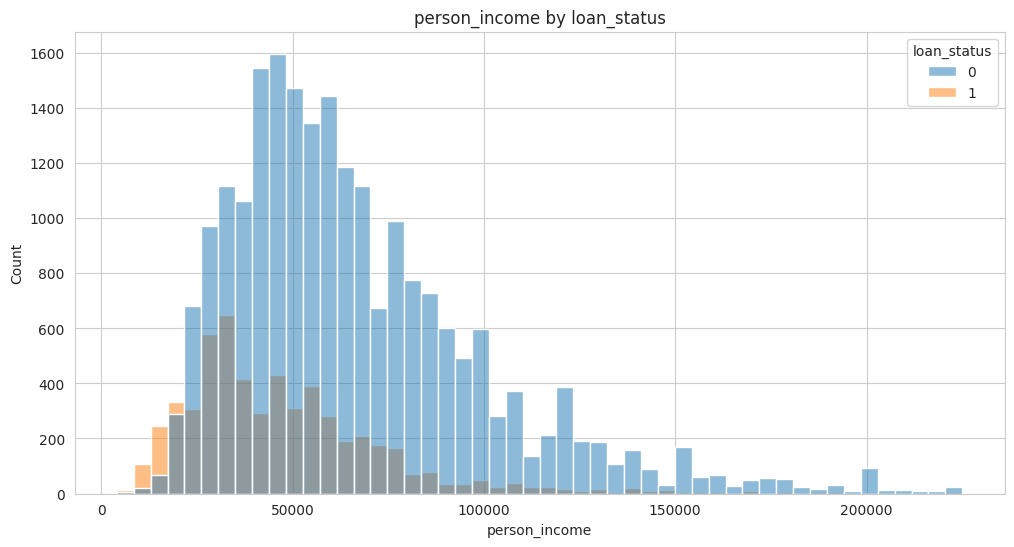

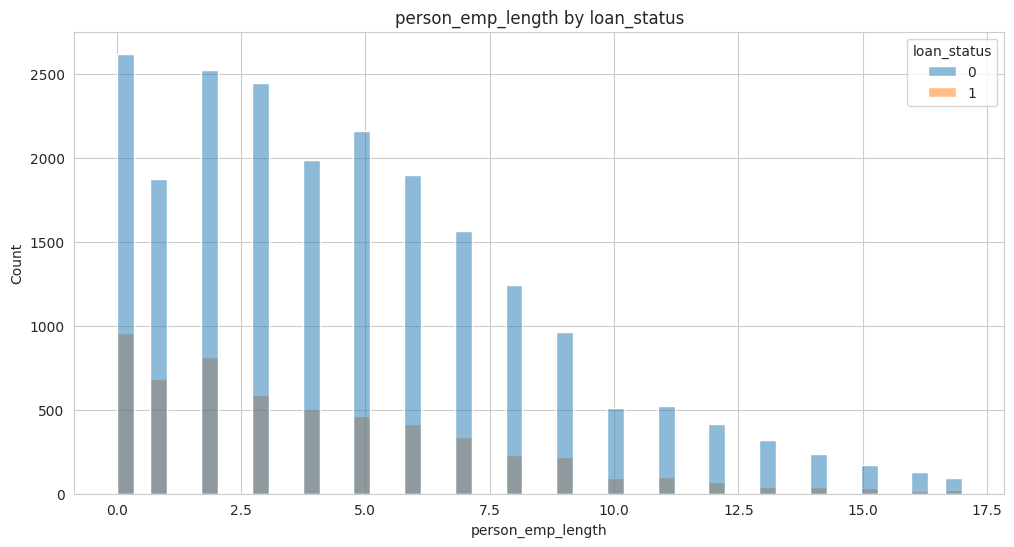

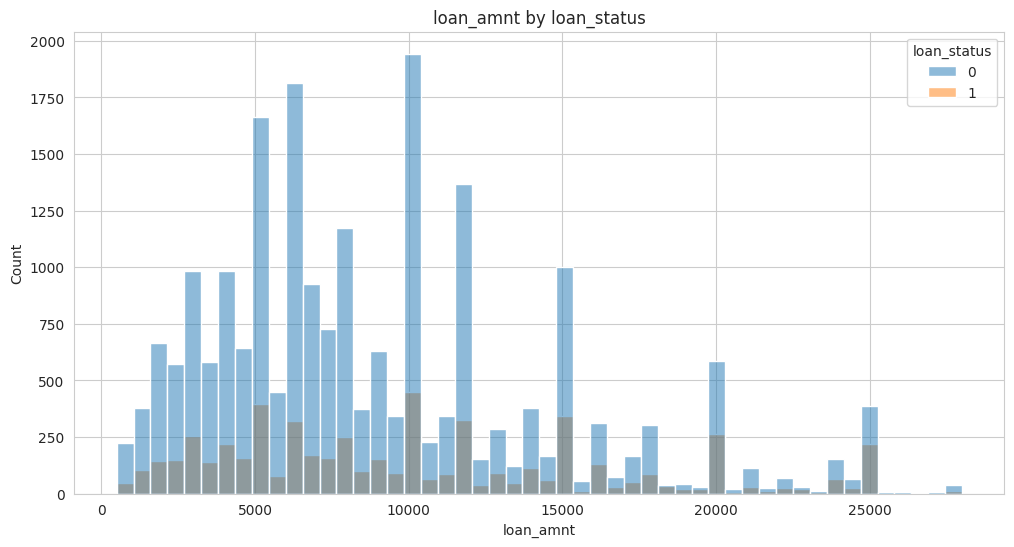

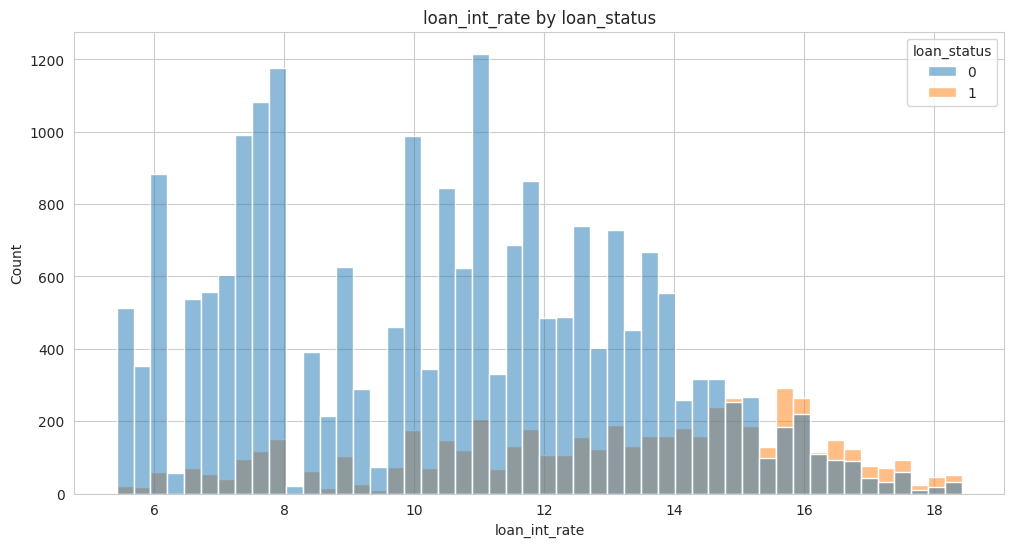

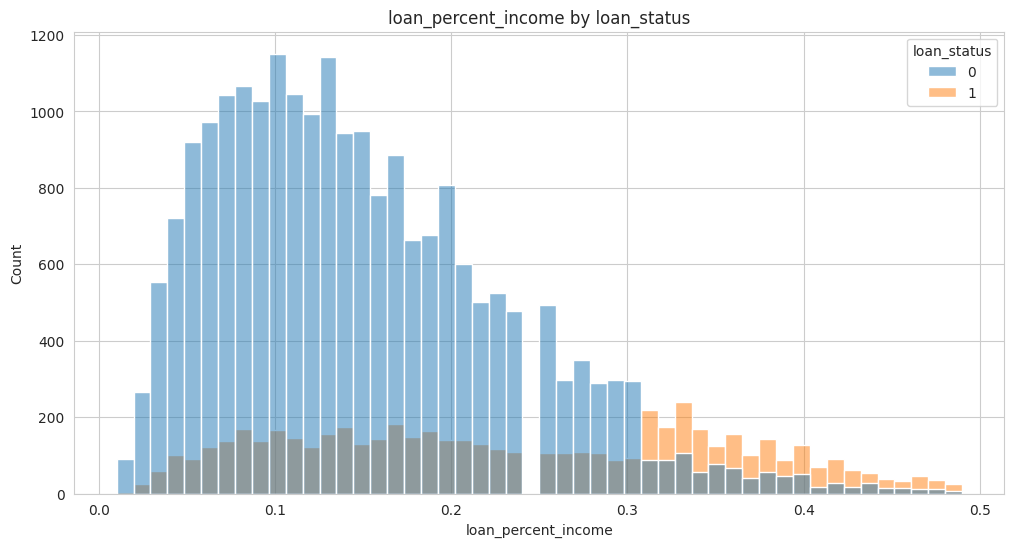

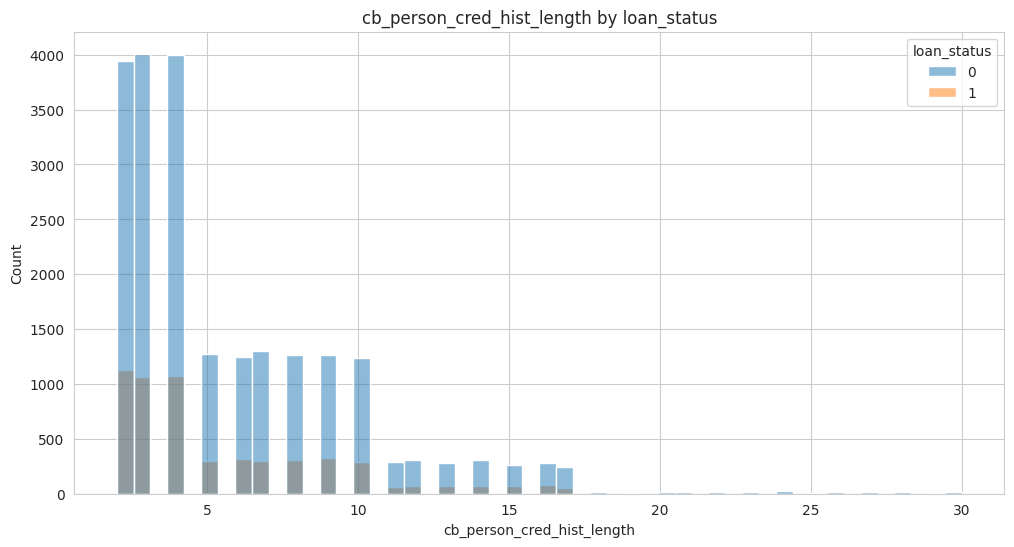

In [17]:
# Числовые признаки
numeric_cols = ['person_age', 'person_income', 'person_emp_length',
                'loan_amnt', 'loan_int_rate', 'loan_percent_income',
                'cb_person_cred_hist_length']

# Распределение по каждому признаку в разрезе target
for col in numeric_cols:
    plt.figure()
    sns.histplot(data=df, x=col, hue='loan_status', bins=50, alpha=0.5)
    plt.title(f'{col} by loan_status')
    plt.show()

<Figure size 1200x600 with 0 Axes>

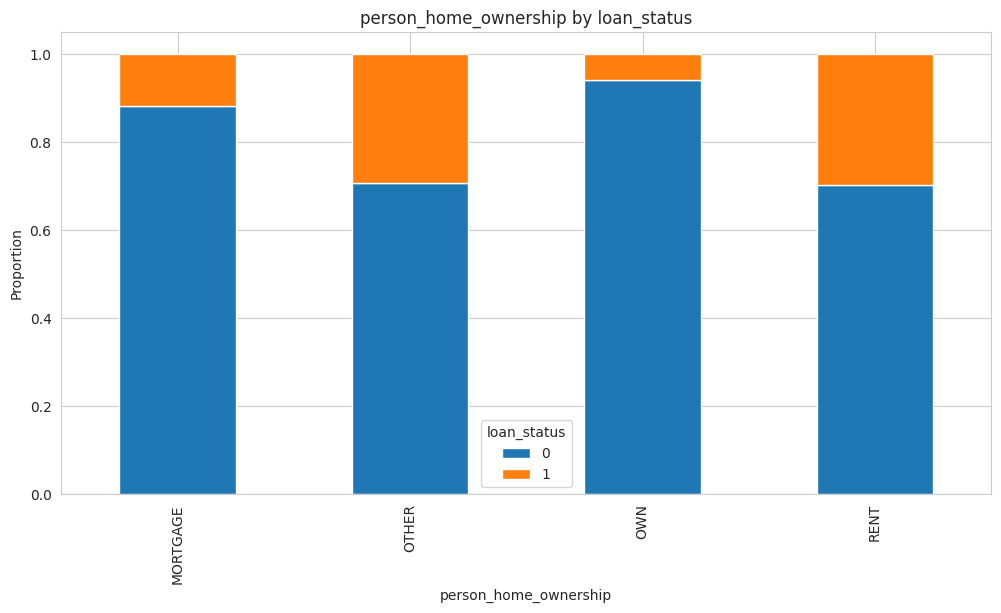

<Figure size 1200x600 with 0 Axes>

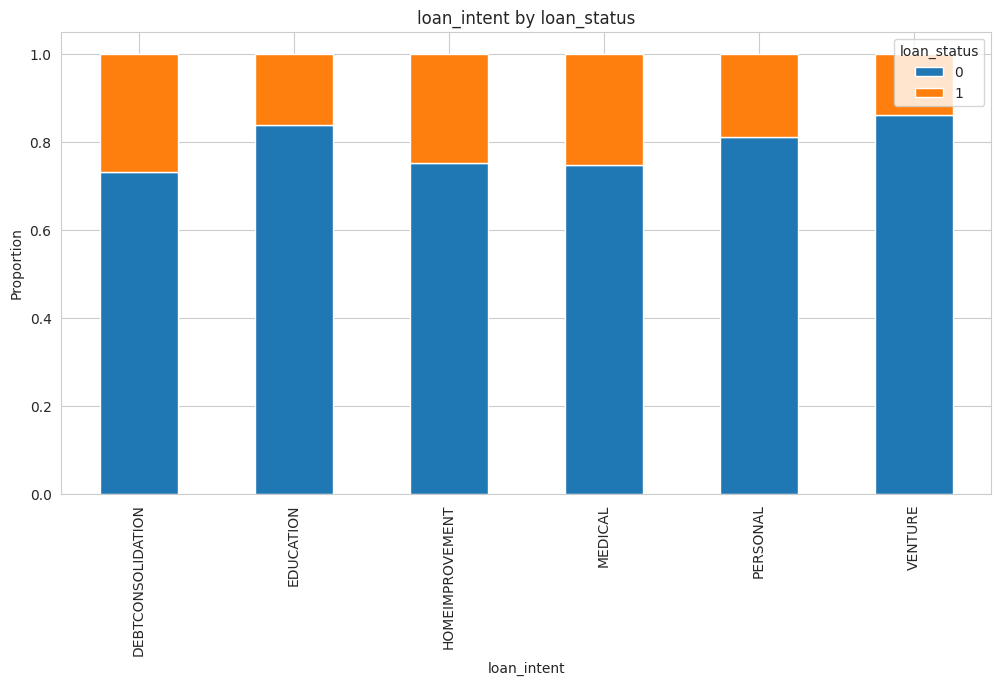

<Figure size 1200x600 with 0 Axes>

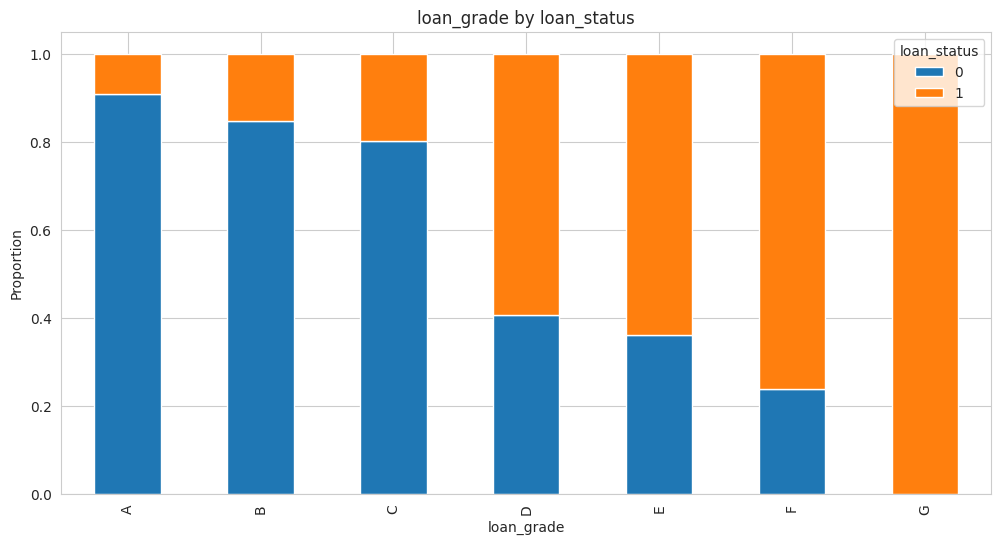

<Figure size 1200x600 with 0 Axes>

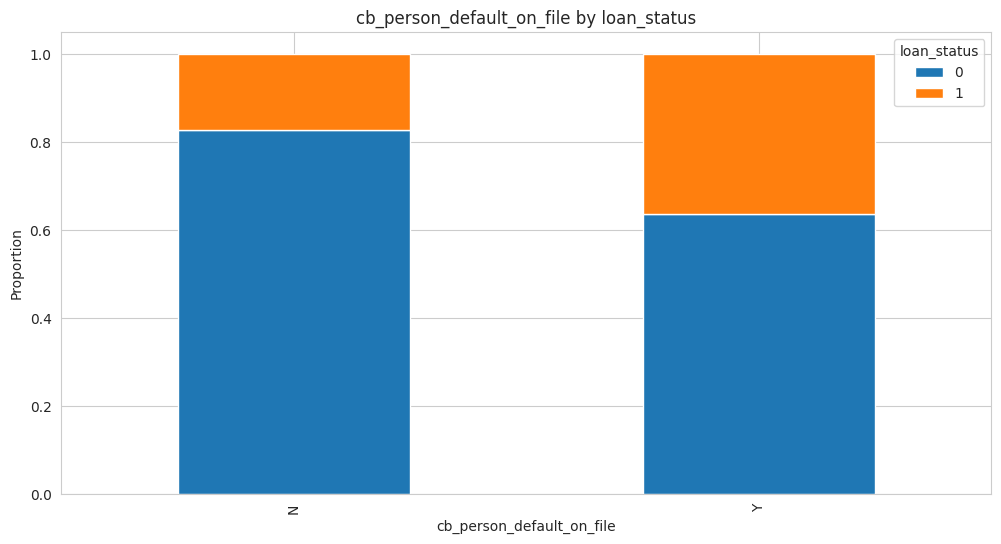

In [18]:
# Категориальные признаки
cat_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

for col in cat_cols:
    plt.figure()
    pd.crosstab(df[col], df['loan_status'], normalize='index').plot(kind='bar', stacked=True)
    plt.title(f'{col} by loan_status')
    plt.ylabel('Proportion')
    plt.show()

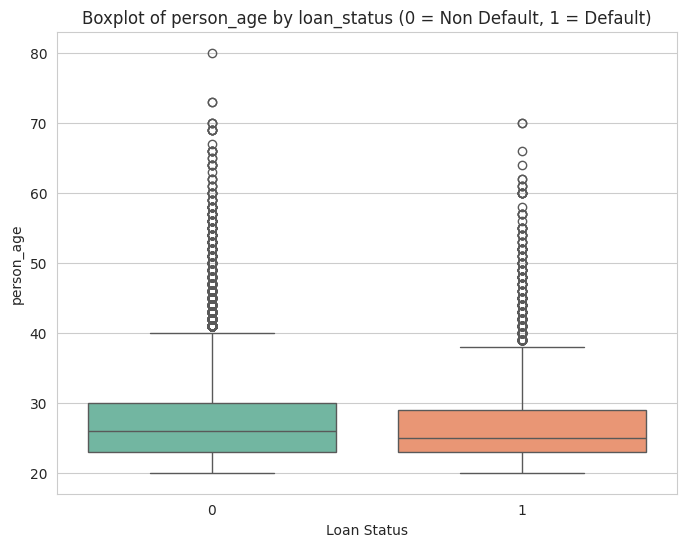

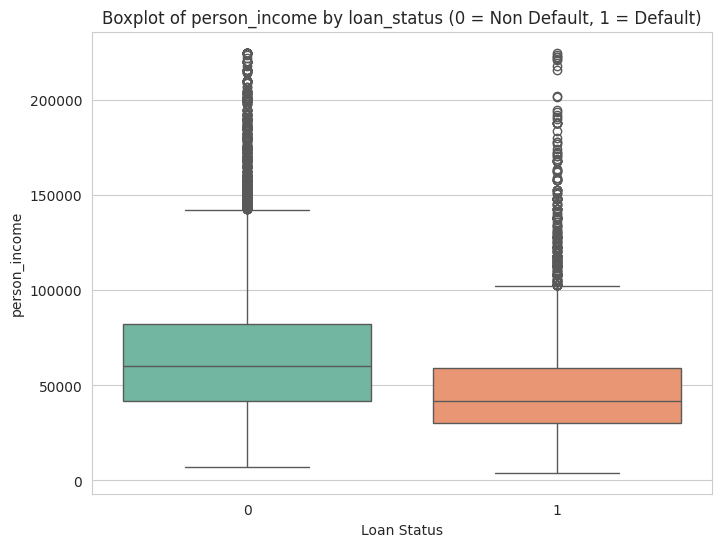

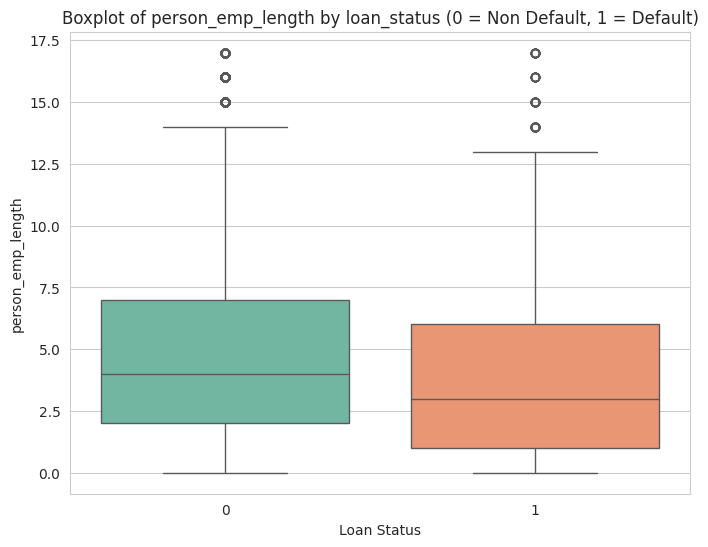

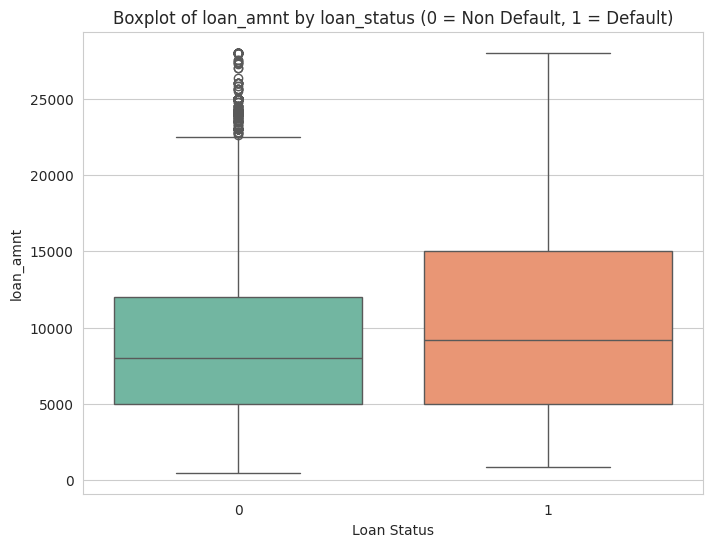

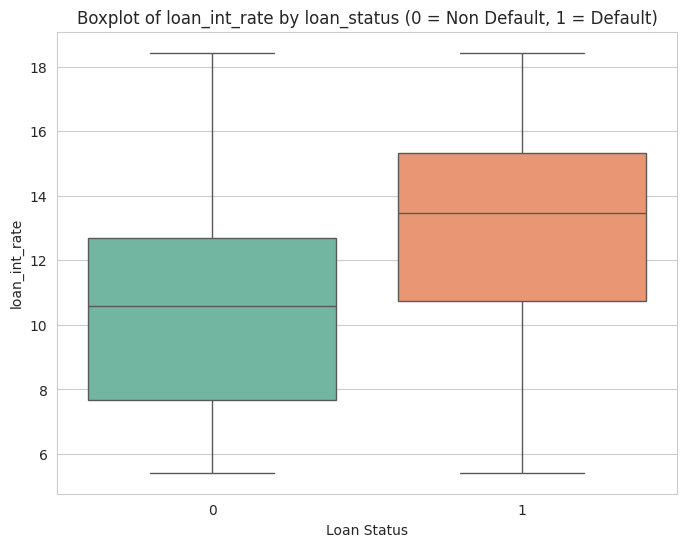

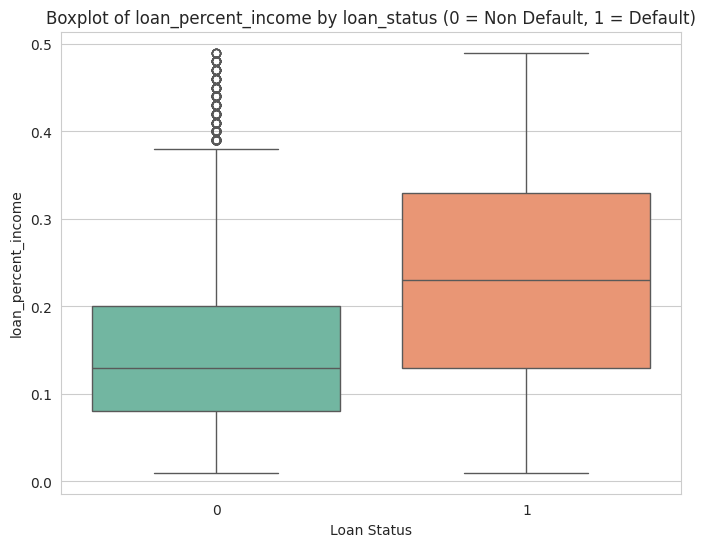

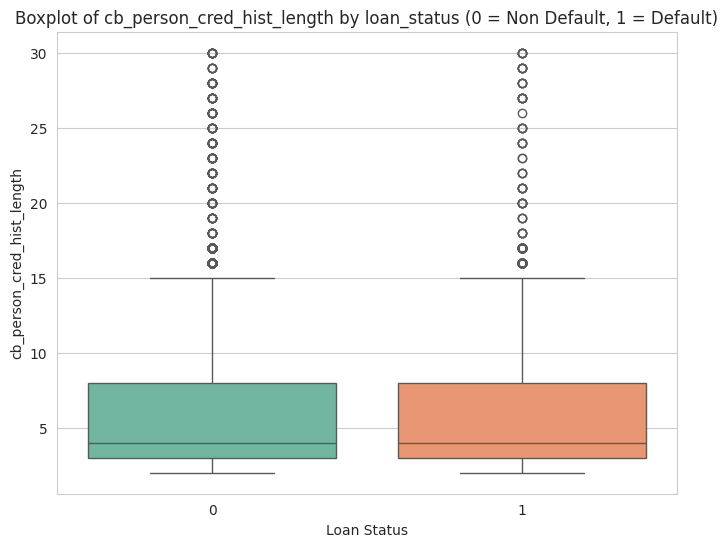

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Числовые признаки (все, кроме целевого)
numeric_cols = ['person_age', 'person_income', 'person_emp_length',
                'loan_amnt', 'loan_int_rate', 'loan_percent_income',
                'cb_person_cred_hist_length']

# Настройка стиля
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Построение boxplot по каждому признаку
for col in numeric_cols:
    plt.figure(figsize=(8, 6))
    sns.boxplot(data=df, x='loan_status', y=col, hue='loan_status',
                palette='Set2', legend=False)
    plt.title(f'Boxplot of {col} by loan_status (0 = Non Default, 1 = Default)')
    plt.xlabel('Loan Status')
    plt.ylabel(col)
    plt.show()

In [ ]:
#выводы
#Факторы, повышающие риск дефолта:
#Возраст: наибольшая доля дефолтов наблюдается в группе 20–30 лет. Заемщики старше 40 лет демонстрируют значительно более низкий уровень дефолтов.
#Стаж работы: основная зона риска — заемщики со стажем от 1 до 10 лет. Короткий трудовой стаж скорее всего связан с нестабильностью дохода/низким уровнем дохода.
#Сумма кредита: пик дефолтов приходится на кредиты около 10 000 $.
#Процентная ставка: при ставке выше 15% доля дефолтов начинает превышать долю добросовестных заемщиков.
#Отношение кредита к доходу (loan_percent_income): при значении коэффициента выше 0,3 наблюдается резкий рост дефолтов.
#Длительность кредитной истории: наибольшее количество дефолтов фиксируется в первые 5 лет кредитной истории.
#Категориальные признаки:
#Тип жилья: наименьший уровень дефолтов у заемщиков, владеющих жильем; наибольший — у категории «другое» и арендаторов.
#Цель кредита: максимальная доля дефолтов — при объединении долгов, ремонте и медицинских расходах. Наименьший риск — у кредитов на бизнес.
#Кредитный класс (loan_grade): распределение дефолтов соответствует ожидаемой логике (чем ниже класс, тем выше риск).
#Наличие дефолта в прошлом: среди заемщиков с историческим дефолтом текущий дефолт составляет 40%; среди тех, у кого не было дефолтов, — только 20%.
#Корреляционный анализ:
#Выявлена мультиколлинеарность между возрастом и длиной кредитной истории (0,86).
#Умеренная корреляция (0,57) между суммой кредита и отношением кредита к доходу.
#Остальные корреляции находятся в диапазоне от -0,25 до 0,38, что указывает на умеренные связи.
#Выводы по очистке данных (обработка выбросов)
#В ходе очистки данных выбросы были выявлены с помощью метода ящиков с усами (boxplots) по следующим признакам:
#возраст (наличие записей старше 80 лет)
#доход (единичные экстремально высокие значения)
#рабочий стаж
#сумма кредита
#процентная ставка
#отношение кредита к доходу
#длина кредитной истории (наблюдалась асимметрия в нижнюю часть, что может являтся естественным распределением)
#Принятые меры:
#Для всех признаков, за исключением длины кредитной истории, применено ограничение на уровне 99-го процентиля.
#Результат очистки:
#Исходное количество записей: 32 581
#После очистки: 27 264
#Удалено: ~16,3% данных

In [ ]:
#Кодирование категориальных признаков

In [20]:
from sklearn.preprocessing import LabelEncoder

cat_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print(df[cat_cols].head())

    person_home_ownership  loan_intent  loan_grade  cb_person_default_on_file
1                       2            1           1                          0
5                       2            5           0                          0
9                       2            5           3                          0
11                      2            2           0                          0
19                      0            1           1                          0


In [ ]:
#Разделение на train/test

In [21]:
from sklearn.model_selection import train_test_split

X = df.drop('loan_status', axis=1)
y = df['loan_status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape}")
print(f"Test size: {X_test.shape}")

Train size: (21811, 11)
Test size: (5453, 11)


In [ ]:
#масштабирование

In [22]:
from sklearn.preprocessing import StandardScaler

# Выбираем только числовые признаки для масштабирования
# (категориальные мы уже закодировали, их тоже можно масштабировать)
numeric_cols = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
                'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']

# Добавляем закодированные категориальные признаки
cat_cols_encoded = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

# Все признаки для масштабирования
all_features = numeric_cols + cat_cols_encoded

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[all_features])
X_test_scaled = scaler.transform(X_test[all_features])

print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")

X_train_scaled shape: (21811, 11)
X_test_scaled shape: (5453, 11)


In [ ]:
#обучение
#логистическая регрессия

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve

# Обучение модели
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)

# Предсказания
y_pred_lr = lr.predict(X_test_scaled)
y_pred_proba_lr = lr.predict_proba(X_test_scaled)[:, 1]

# Метрики
print("=== ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ ===")
print(classification_report(y_test, y_pred_lr))
print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_proba_lr):.3f}")

# Матрица ошибок
cm_lr = confusion_matrix(y_test, y_pred_lr)
print(f"Confusion Matrix:\n{cm_lr}")

=== ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ ===
              precision    recall  f1-score   support

           0       0.87      0.95      0.91      4330
           1       0.71      0.43      0.53      1123

    accuracy                           0.85      5453
   macro avg       0.79      0.69      0.72      5453
weighted avg       0.83      0.85      0.83      5453

AUC-ROC: 0.846
Confusion Matrix:
[[4129  201]
 [ 641  482]]


In [24]:
#random forest

In [25]:
from sklearn.ensemble import RandomForestClassifier

# Обучение модели
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)

# Предсказания
y_pred_rf = rf.predict(X_test_scaled)
y_pred_proba_rf = rf.predict_proba(X_test_scaled)[:, 1]

# Метрики
print("\n=== RANDOM FOREST ===")
print(classification_report(y_test, y_pred_rf))
print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_proba_rf):.3f}")

# Матрица ошибок
cm_rf = confusion_matrix(y_test, y_pred_rf)
print(f"Confusion Matrix:\n{cm_rf}")


=== RANDOM FOREST ===
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      4330
           1       0.97      0.69      0.81      1123

    accuracy                           0.93      5453
   macro avg       0.95      0.84      0.88      5453
weighted avg       0.93      0.93      0.93      5453

AUC-ROC: 0.933
Confusion Matrix:
[[4305   25]
 [ 349  774]]


In [ ]:
#Анализ важности признаков


=== ВАЖНОСТЬ ПРИЗНАКОВ (Random Forest) ===
                       feature  importance
5                   loan_grade    0.221493
1                person_income    0.146206
4                  loan_intent    0.117050
9    cb_person_default_on_file    0.115390
7                loan_int_rate    0.091919
3            person_emp_length    0.075998
8          loan_percent_income    0.071472
2        person_home_ownership    0.067091
0                   person_age    0.045287
6                    loan_amnt    0.035952
10  cb_person_cred_hist_length    0.012141


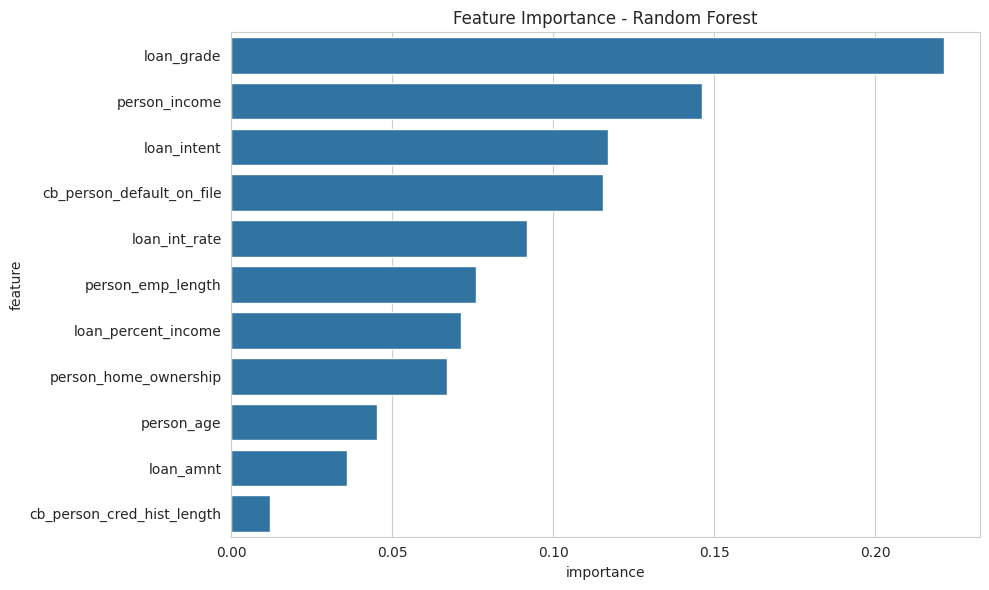

In [27]:
# Важность признаков
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\n=== ВАЖНОСТЬ ПРИЗНАКОВ (Random Forest) ===")
print(feature_importance)

# Визуализация
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='importance', y='feature')
plt.title('Feature Importance - Random Forest')
plt.tight_layout()
plt.show()

In [ ]:
#Gradient Boosting

In [26]:
from sklearn.ensemble import GradientBoostingClassifier

# Обучение модели
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train_scaled, y_train)

# Предсказания
y_pred_gb = gb.predict(X_test_scaled)
y_pred_proba_gb = gb.predict_proba(X_test_scaled)[:, 1]

# Метрики
print("\n=== GRADIENT BOOSTING ===")
print(classification_report(y_test, y_pred_gb))
print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_proba_gb):.3f}")

# Матрица ошибок
cm_gb = confusion_matrix(y_test, y_pred_gb)
print(f"Confusion Matrix:\n{cm_gb}")



=== GRADIENT BOOSTING ===
              precision    recall  f1-score   support

           0       0.92      0.99      0.95      4330
           1       0.93      0.67      0.78      1123

    accuracy                           0.92      5453
   macro avg       0.92      0.83      0.87      5453
weighted avg       0.92      0.92      0.92      5453

AUC-ROC: 0.929
Confusion Matrix:
[[4271   59]
 [ 368  755]]


In [ ]:
#Лучшая модель (Random Forest) показывает точность 97% при выявлении 69% реальных дефолтов. Ключевые факторы риска: кредитный класс, доход, цель кредита, история дефолтов.